In [1]:
import os
import pandas as pd
import geopandas as gpd
import rasterio
import re
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import ttest_ind

In [2]:
# user-defined paths
base_dir = '../../../../datos-notebooks/3.global-data-cba/'
ground_data_name = 'ground_data_170226_shadow_sun.csv'

In [3]:
# derived paths
ground_data_path = os.path.join(base_dir, 'MRT-prediction/ground_data', ground_data_name)

In [4]:
df = pd.read_csv(ground_data_path, sep=",")

#### correcting T1 values
TG1_corr = 0.639 * TG1 + 9.681 from notebook 3.4.4.1.

TG1: Sper Scientific 800036

TG2: TM-188D TENMARS

In [5]:
# Create corrected TG column based on instrument used
df["tg_corr"] = np.where(
    df["instrument (1 viejo 2 nuevo)"] == 1,
    0.639 * df["TG"] + 9.681,   # apply correction for A1 based on notebook 3.4.4.1.
    df["TG"]                   # keep original value for A2
)

In [6]:
# Convert time to datetime
df["time"] = pd.to_datetime(df["time"], format="%H:%M")

fig = px.scatter(
    df,
    x="time",
    y="tg_corr",
    color="condition",
    color_discrete_map={
        "sun": "orange",
        "shadow": "blue"
    },
    hover_data=["TG", "tg_corr", "wind"],
    title="TG in time (corrected)"
)

fig.show()

In [7]:
df

,time,instrument (1 viejo 2 nuevo),TA (a),TA (t),TG,condition,wind,obs 1,obs 2,tg_corr
0,1900-01-01 12:04:00,2,NaN,26.5,30.5,sun,NaN,en mano,NaN,30.5000
1,1900-01-01 12:04:00,1,NaN,26.5,35.4,shadow,NaN,en mano,NaN,32.3016
2,1900-01-01 12:05:00,2,NaN,26.5,32.5,sun,NaN,en mano,NaN,32.5000
3,1900-01-01 12:05:00,2,NaN,26.5,33.6,shadow,NaN,en mano,NaN,33.6000
4,1900-01-01 12:06:00,2,NaN,27.5,34.8,sun,NaN,en mano,NaN,34.8000
5,1900-01-01 12:08:00,2,26.1,27.9,37.6,sun,0.0,sobre caja negra,NaN,37.6000
6,1900-01-01 12:09:00,1,26.5,29.8,31.8,shadow,0.3,silleta negra,NaN,30.0012
7,1900-01-01 12:09:00,2,26.7,28.8,39.2,sun,0.0,caja negra,NaN,39.2000
8,1900-01-01 12:10:00,1,27.0,29.3,29.9,shadow,0.5,silleta negra,NaN,28.7871
9,1900-01-01 12:10:00,2,27.6,29.2,40.2,sun,0.0,caja negra,NaN,40.2000


#### MRT computing

In [22]:
# Fill NaN values
df["TA (t)"] = df["TA (t)"].fillna(29.5)
df["wind"] = df["wind"].fillna(0.00)

t1 = df[df["instrument (1 viejo 2 nuevo)"] == "1"]["wind"]
t2 = df[df["instrument (1 viejo 2 nuevo)"] == "2"]["wind"]

t1_min, t1_max = t1.min(), t1.max()
t2_min, t2_max = t2.min(), t2.max()

df.loc[df["instrument (1 viejo 2 nuevo)"] == "2", "wind_corr"] = \
    t1_min + (t2 - t2_min) / (t2_max - t2_min) * (t1_max - t1_min)

# T1 queda igual
df.loc[df["instrument (1 viejo 2 nuevo)"] == "1", "wind_corr"] = t1.values

In [23]:
# Fill NaN values
df["TA (t)"] = df["TA (t)"].fillna(29.5)
df["wind"] = df["wind"].fillna(0.00)

# Wind was measured with A2 anemometer - corrections are made based on notebook 3.4.4.2.
df["wind_corr"] = (df["wind"] - 1.0102) / 0.8785
df["wind_corr"] = np.where(df["wind_corr"] <= 0, 0.01, df["wind_corr"]) # set minimum 0.01 to avoid issues

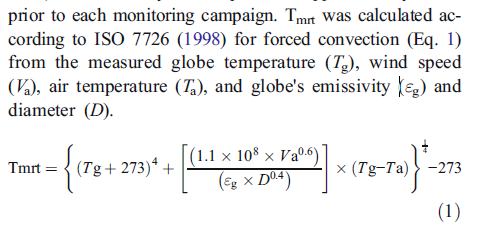

In [24]:
# Parameters
eps = 0.95
D1 = 0.04   # diameter of globe 1 [m] 
D2 = 0.05  # diameter of globe 2 [m] 

# Select diameter according to instrument
D = np.where(df["instrument (1 viejo 2 nuevo)"] == 1, D1,D2)

# MRT calculation using row-specific diameter
df["MRT"] = (
    (
        (df["tg_corr"] + 273.15)**4
        + (1.1e8 * df["wind_corr"]  **0.6 / (eps * D2**0.4)) * (df["tg_corr"] - df["TA (t)"]) # use D2 because TG values are calibrated to Thermometer 2
    )**0.25
    - 273.15
)

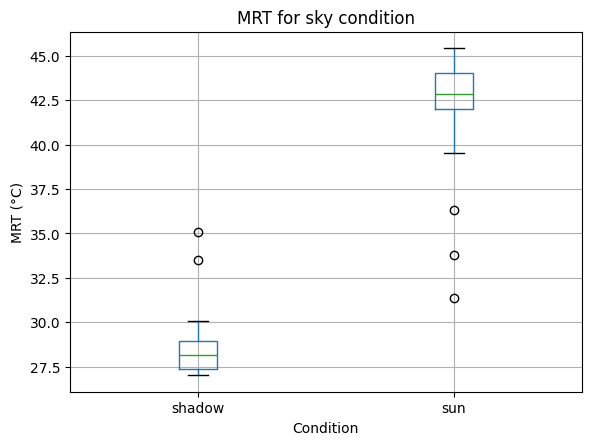

In [25]:
# Boxplot of corrected MRT by condition
df.boxplot(column="MRT", by="condition")

plt.title("MRT for sky condition")
plt.suptitle("")  
plt.xlabel("Condition")
plt.ylabel("MRT (°C)")
plt.show()


In [26]:
fig = px.scatter(
    df,
    x="time",
    y="MRT",
    color="condition",
    color_discrete_map={
        "sun": "orange",
        "shadow": "blue"
    },
    hover_data=["TG", "MRT", "wind", "obs 1", "instrument (1 viejo 2 nuevo)"],
    title="MRT in time "
)

fig.show()

The values in the first 10' show the time that takes for each thermometer to adapt. Those values are filtered below

In [27]:
df_filtrado = df[df["time"] >= pd.to_datetime("12:09", format="%H:%M")]

In [28]:
df_filtrado

,time,instrument (1 viejo 2 nuevo),TA (a),TA (t),TG,condition,wind,obs 1,obs 2,tg_corr,wind_norm,wind_corr,MRT
6,1900-01-01 12:09:00,1,26.5,29.8,31.8,shadow,0.3,silleta negra,NaN,30.0012,NaN,0.01,30.044910
7,1900-01-01 12:09:00,2,26.7,28.8,39.2,sun,0.0,caja negra,NaN,39.2000,NaN,0.01,41.245811
8,1900-01-01 12:10:00,1,27.0,29.3,29.9,shadow,0.5,silleta negra,NaN,28.7871,NaN,0.01,28.674238
9,1900-01-01 12:10:00,2,27.6,29.2,40.2,sun,0.0,caja negra,NaN,40.2000,NaN,0.01,42.342267
10,1900-01-01 12:11:00,1,28.1,28.8,28.8,shadow,0.0,silleta negra,NaN,28.0842,NaN,0.01,27.925549
11,1900-01-01 12:11:00,2,28.3,30.0,41.3,sun,0.4,caja negra,NaN,41.3000,NaN,0.01,43.477391
12,1900-01-01 12:12:00,1,28.7,28.6,28.2,shadow,0.0,silleta negra,NaN,27.7008,NaN,0.01,27.500695
13,1900-01-01 12:12:00,2,29.1,29.1,42.0,sun,0.0,caja negra,NaN,42.0000,NaN,0.01,44.465841
14,1900-01-01 12:12:00,2,29.1,29.1,41.8,sun,0.0,en mano,NaN,41.8000,NaN,0.01,44.232605
15,1900-01-01 12:14:00,1,29.1,29.1,28.0,shadow,0.0,silleta negra,NaN,27.5730,NaN,0.01,27.232515


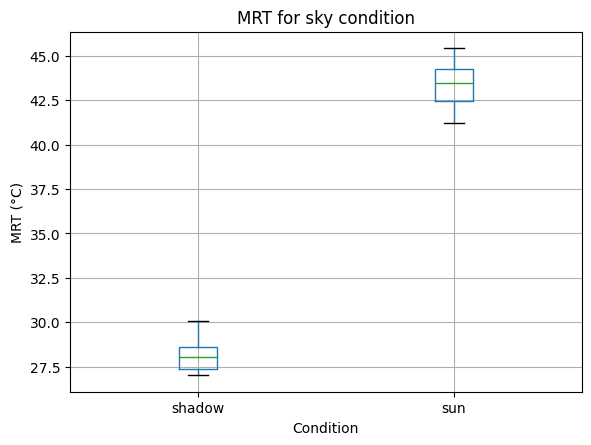

In [29]:
# Boxplot of corrected and filtered MRT by condition
df_filtrado.boxplot(column="MRT", by="condition")

plt.title("MRT for sky condition")
plt.suptitle("") 
plt.xlabel("Condition")
plt.ylabel("MRT (°C)")
plt.show()

In [30]:
# Compute mean by condition
means = df_filtrado.groupby("condition")["MRT"].mean()

# Difference sun - shadow
diff = means["sun"] - means["shadow"]
diff = round(diff, 2)

means, diff

(condition
 shadow    28.077227
 sun       43.342674
 Name: MRT, dtype: float64,
 np.float64(15.27))

In [31]:
# t-test
sun = df_filtrado[df_filtrado["condition"] == "sun"]["MRT"]
shadow = df_filtrado[df_filtrado["condition"] == "shadow"]["MRT"]

ttest_ind(sun, shadow, equal_var=False) 

TtestResult(statistic=np.float64(42.504890207859916), pvalue=np.float64(6.515060692221795e-29), df=np.float64(30.797609584487784))

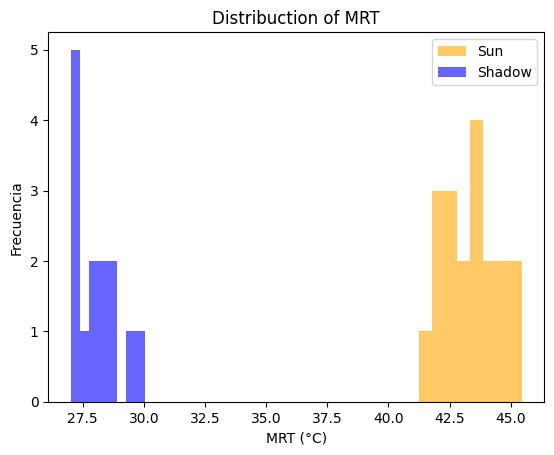

In [32]:
sun = df_filtrado[df_filtrado["condition"] == "sun"]["MRT"]
shadow = df_filtrado[df_filtrado["condition"] == "shadow"]["MRT"]

plt.hist(sun, bins=8, alpha=0.6, label="Sun", color="orange")
plt.hist(shadow, bins=8, alpha=0.6, label="Shadow", color="blue")

plt.xlabel("MRT (°C)")
plt.ylabel("Frecuencia")
plt.title("Distribuction of MRT")
plt.legend()
plt.show()

diferencias ta y MRT


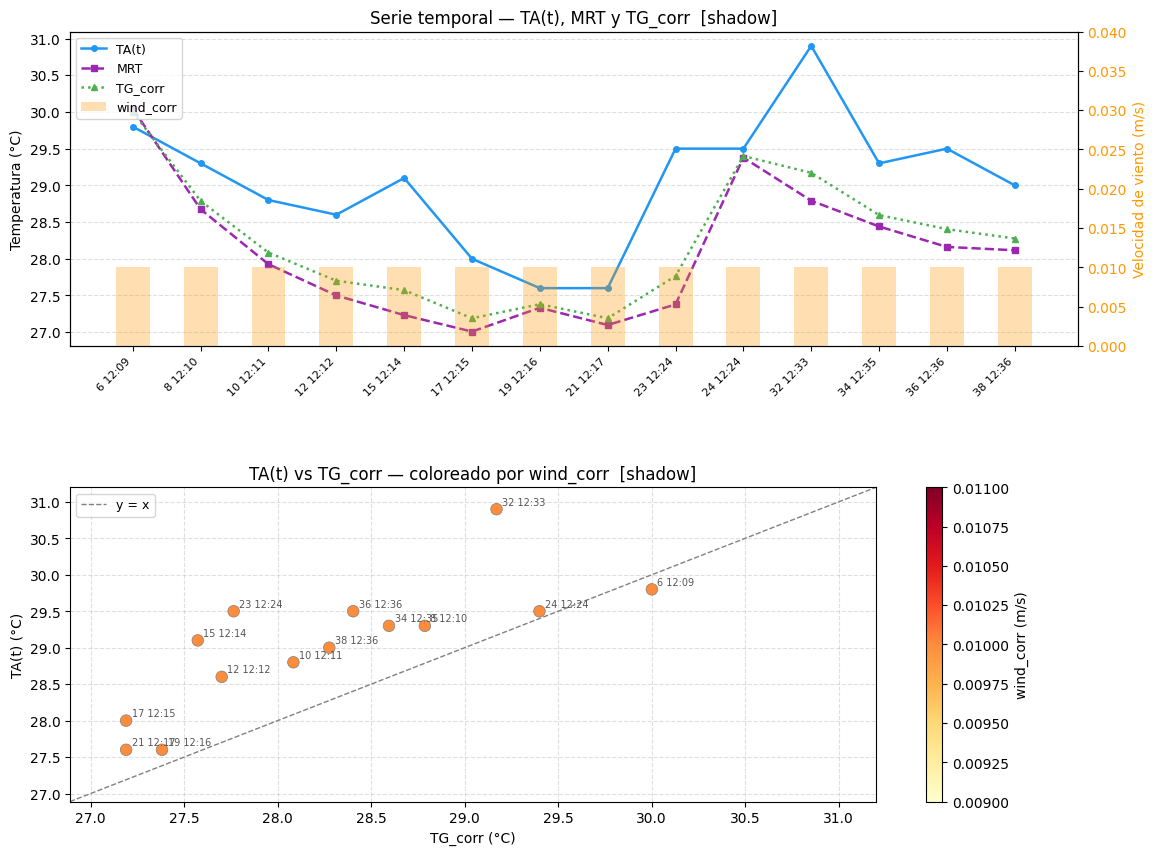

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Filtro shadow ──────────────────────────────────────────────────────────────
df = df_filtrado[df_filtrado["condition"] == "shadow"].copy().reset_index()
df["label"] = df["index"].astype(str) + " " + df["time"].astype(str).str[-8:-3]

x = np.arange(len(df))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10))
fig.subplots_adjust(hspace=0.45)

# ── 1. Serie temporal con eje secundario para wind_corr ───────────────────────
ax1.plot(x, df["TA (t)"],   marker="o", ms=4, linewidth=1.8, label="TA(t)",    color="#2196F3")
ax1.plot(x, df["MRT"],      marker="s", ms=4, linewidth=1.8, label="MRT",      color="#9C27B0", linestyle="--")
ax1.plot(x, df["tg_corr"],  marker="^", ms=4, linewidth=1.8, label="TG_corr",  color="#4CAF50", linestyle=":")
ax1.set_xticks(x)
ax1.set_xticklabels(df["label"], rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("Temperatura (°C)")
ax1.set_title("Serie temporal — TA(t), MRT y TG_corr  [shadow]", fontsize=12)

ax1_wind = ax1.twinx()
ax1_wind.bar(x, df["wind_corr"], color="#FF9800", alpha=0.3, width=0.5, label="wind_corr")
ax1_wind.set_ylabel("Velocidad de viento (m/s)", color="#FF9800")
ax1_wind.tick_params(axis="y", labelcolor="#FF9800")
ax1_wind.set_ylim(0, df["wind_corr"].max() * 4)

# leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_wind.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# ── 2. Scatter TA(t) vs TG_corr coloreado por wind_corr ──────────────────────
sc = ax2.scatter(df["tg_corr"], df["TA (t)"],
                 c=df["wind_corr"], cmap="YlOrRd", s=70, zorder=3,
                 edgecolors="gray", linewidths=0.5)
plt.colorbar(sc, ax=ax2, label="wind_corr (m/s)")

lims = [min(df["tg_corr"].min(), df["TA (t)"].min()) - 0.3,
        max(df["tg_corr"].max(), df["TA (t)"].max()) + 0.3]
ax2.plot(lims, lims, "--", color="gray", linewidth=1, label="y = x")
ax2.set_xlim(lims); ax2.set_ylim(lims)

for _, row in df.iterrows():
    ax2.annotate(row["label"], (row["tg_corr"], row["TA (t)"]),
                 fontsize=7, color="#555", xytext=(4, 3), textcoords="offset points")

ax2.set_xlabel("TG_corr (°C)")
ax2.set_ylabel("TA(t) (°C)")
ax2.set_title("TA(t) vs TG_corr — coloreado por wind_corr  [shadow]", fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(linestyle="--", alpha=0.4)

plt.show()